# Scheme Success - Optimized

## Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RepeatedKFold, cross_val_score, learning_curve
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import ElasticNet
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import r2_score, accuracy_score, f1_score, classification_report
import joblib

df = pd.read_csv("../data/raw/historical_scheme_data.csv")
df["EMI_to_Price_Ratio"] = df["Monthly_EMI_INR"] / df["Price_INR"]
df["AdBudget_per_Sqft"] = df["Advertising_Budget_INR"] / df["Plot_Size_SqFt"]

input_features = ["Location", "Plot_Size_SqFt", "Price_INR", "Monthly_EMI_INR",
                   "Park", "Clubhouse", "Distance_from_Metro_km", "Advertising_Budget_INR",
                   "EMI_to_Price_Ratio", "AdBudget_per_Sqft"]
target_cols = ["Expected_Leads", "Expected_Bookings", "Estimated_Conversion_Pct", "Scheme_Success_Score"]


## Part 1 - Regression Baseline

In [2]:
X = pd.get_dummies(df[input_features], columns=["Location", "Park", "Clubhouse"], drop_first=True)
y = df[target_cols]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = MinMaxScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

prev_reg = joblib.load("../models/scheme_multi_output_model.pkl")
prev_r2 = r2_score(y_test, prev_reg.predict(X_test_s), multioutput="uniform_average")
print(f"Original Best (scheme_success_model.ipynb): avg R2={prev_r2:.3f}")


Original Best (scheme_success_model.ipynb): avg R2=0.733


## Small-Sample Diagnosis - Repeated Cross-Validation

In [3]:
rkf = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)
rf_cv_scores = cross_val_score(RandomForestRegressor(n_estimators=200, random_state=42), X_train_s, y_train, cv=rkf, scoring="r2")
print(f"Random Forest, 5x5 repeated CV: mean R2={rf_cv_scores.mean():.3f}  std={rf_cv_scores.std():.3f}  range=[{rf_cv_scores.min():.3f}, {rf_cv_scores.max():.3f}]")


Random Forest, 5x5 repeated CV: mean R2=0.650  std=0.033  range=[0.562, 0.712]


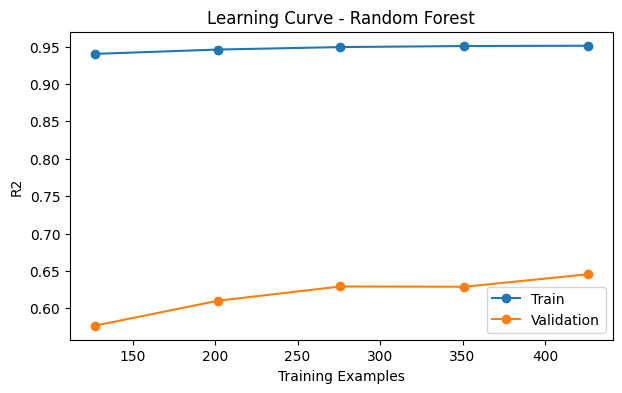

In [4]:
train_sizes, train_scores, val_scores = learning_curve(
    RandomForestRegressor(n_estimators=200, random_state=42), X_train_s, y_train,
    train_sizes=np.linspace(0.3, 1.0, 5), cv=3, scoring="r2"
)
plt.figure(figsize=(7,4))
plt.plot(train_sizes, train_scores.mean(axis=1), "o-", label="Train")
plt.plot(train_sizes, val_scores.mean(axis=1), "o-", label="Validation")
plt.xlabel("Training Examples"); plt.ylabel("R2"); plt.title("Learning Curve - Random Forest")
plt.legend(); plt.show()


## New Technique - Tuned ElasticNet

In [5]:
en_model = MultiOutputRegressor(ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42, max_iter=5000))
en_model.fit(X_train_s, y_train)
en_r2 = r2_score(y_test, en_model.predict(X_test_s), multioutput="uniform_average")
print(f"ElasticNet: avg R2={en_r2:.3f}")
print(f"Original: R2={prev_r2:.3f}  |  ElasticNet: R2={en_r2:.3f}")


ElasticNet: avg R2=0.669
Original: R2=0.733  |  ElasticNet: R2=0.669


In [6]:
if en_r2 > prev_r2:
    joblib.dump(en_model, "../models/scheme_multi_output_model_v2.pkl")
    joblib.dump(scaler, "../models/scheme_reg_scaler_v2.pkl")
    joblib.dump(list(X.columns), "../models/scheme_reg_columns_v2.pkl")
    print(f"Saved as *_v2.pkl - improved R2 {prev_r2:.3f} -> {en_r2:.3f}")
else:
    print(f"Original model kept - ElasticNet R2 {en_r2:.3f} did not beat {prev_r2:.3f}")


Original model kept - ElasticNet R2 0.669 did not beat 0.733


## Part 2 - Classification Baseline

In [7]:
yc = df["Demand_Level"]
Xc = pd.get_dummies(df[input_features], columns=["Location", "Park", "Clubhouse"], drop_first=True)
Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.2, random_state=42, stratify=yc)
clf_scaler = MinMaxScaler()
Xc_train_s = clf_scaler.fit_transform(Xc_train)
Xc_test_s = clf_scaler.transform(Xc_test)

prev_clf = joblib.load("../models/scheme_demand_classifier.pkl")
prev_pred = prev_clf.predict(Xc_test_s)
prev_acc = accuracy_score(yc_test, prev_pred)
prev_f1 = f1_score(yc_test, prev_pred, average="macro")
print(f"Original Best: accuracy={prev_acc:.3f}  macro-F1={prev_f1:.3f}")


Original Best: accuracy=0.787  macro-F1=0.787


## New Technique - Repeated CV Model Selection

In [8]:
rf_cv = cross_val_score(RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42), Xc_train_s, yc_train, cv=rkf, scoring="f1_macro")
print(f"Random Forest, 5x5 repeated CV: mean macro-F1={rf_cv.mean():.3f}  std={rf_cv.std():.3f}")

new_clf = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight="balanced", random_state=42)
new_clf.fit(Xc_train_s, yc_train)
new_pred = new_clf.predict(Xc_test_s)
new_acc = accuracy_score(yc_test, new_pred)
new_f1 = f1_score(yc_test, new_pred, average="macro")
print(f"Held-out test: accuracy={new_acc:.3f}  macro-F1={new_f1:.3f}")
print(f"Original: macro-F1={prev_f1:.3f}  |  New: macro-F1={new_f1:.3f}")


Random Forest, 5x5 repeated CV: mean macro-F1=0.676  std=0.043


Held-out test: accuracy=0.775  macro-F1=0.779
Original: macro-F1=0.787  |  New: macro-F1=0.779


In [9]:
if new_f1 > prev_f1:
    joblib.dump(new_clf, "../models/scheme_demand_classifier_v2.pkl")
    joblib.dump(clf_scaler, "../models/scheme_demand_scaler_v2.pkl")
    joblib.dump(list(Xc.columns), "../models/scheme_demand_columns_v2.pkl")
    print(f"Saved as *_v2.pkl - improved macro-F1 {prev_f1:.3f} -> {new_f1:.3f}")
else:
    print(f"Original model kept - new macro-F1 {new_f1:.3f} did not beat {prev_f1:.3f}")


Original model kept - new macro-F1 0.779 did not beat 0.787
